# Exercise Sheet 1 — Univariate Exploratory Data Analysis & Distributions
**Course:** Big Data Science in Finance (WI3436TU)
**Assets:** SPY (S&P 500 ETF), AAPL (Apple Inc.)
**Sample window:** 2022-01-01 to 2025-12-31

This notebook works through Problems 1-4 of Exercise Sheet 1, continuing with the daily
log-return series constructed in Exercise Sheet 0. Code cells compute the required
quantities and produce the plots; markdown cells contain the written discussion and proofs.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.optimize
import statsmodels.api as sm
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:0.6f}")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

TICKERS = ["SPY", "AAPL"]
START_DATE = "2022-01-01"
END_DATE = "2025-12-31"

In [2]:
def download_prices(ticker, start_date, end_date):
    """Download raw OHLC(V) + Adj Close data for a single ticker.

    yfinance treats `end` as exclusive, so we push it one day forward to make
    end_date inclusive. If end_date itself is not a trading day, the download
    naturally stops at the closest previous trading day.
    """
    end_inclusive = (pd.Timestamp(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    df = yf.download(
        ticker,
        start=start_date,
        end=end_inclusive,
        auto_adjust=False,   # keep Close and Adj Close as separate columns
        progress=False,
    )
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = pd.to_datetime(df.index)
    return df.sort_index()


def choose_price_series(df):
    """S_t := Adj Close if available, otherwise Close (never mixed within an asset)."""
    if "Adj Close" in df.columns and df["Adj Close"].notna().any():
        col = "Adj Close"
    else:
        col = "Close"
    return df[col].rename("Price"), col

### Price and log-return series

Continue with the return series constructed in Sheet 0: for each ticker, download prices,
select $S_t$ (Adj Close if available, otherwise Close — never mixed within an asset), use
trading days only, drop missing prices before computing returns, and define daily
log-returns $r_t := \log(S_t) - \log(S_{t-1})$.

In [3]:
prices = {}
price_cols = {}
returns = {}

for ticker in TICKERS:
    raw = download_prices(ticker, START_DATE, END_DATE)
    price, col = choose_price_series(raw)
    price = price.dropna()
    prices[ticker] = price
    price_cols[ticker] = col
    returns[ticker] = np.log(price).diff().dropna().rename(ticker)

for ticker in TICKERS:
    r = returns[ticker]
    print(f"{ticker}: price column = {price_cols[ticker]}, "
          f"n = {len(r)} log-returns, "
          f"range {r.index.min().date()} to {r.index.max().date()}")

SPY: price column = Adj Close, n = 1002 log-returns, range 2022-01-04 to 2025-12-31
AAPL: price column = Adj Close, n = 1002 log-returns, range 2022-01-04 to 2025-12-31


## Problem 1

### a) Density histograms

For each asset and each $B \in \{30, 60, 120\}$ equally spaced bins, using the empirical
0.1% and 99.9% quantiles for the displayed x-axis limits:

i) Plot the (normalized) density histogram.

ii) Describe what changes in the center and tails when $B$ increases.

iii) Verify numerically that the sum of bar areas is one, up to numerical rounding.

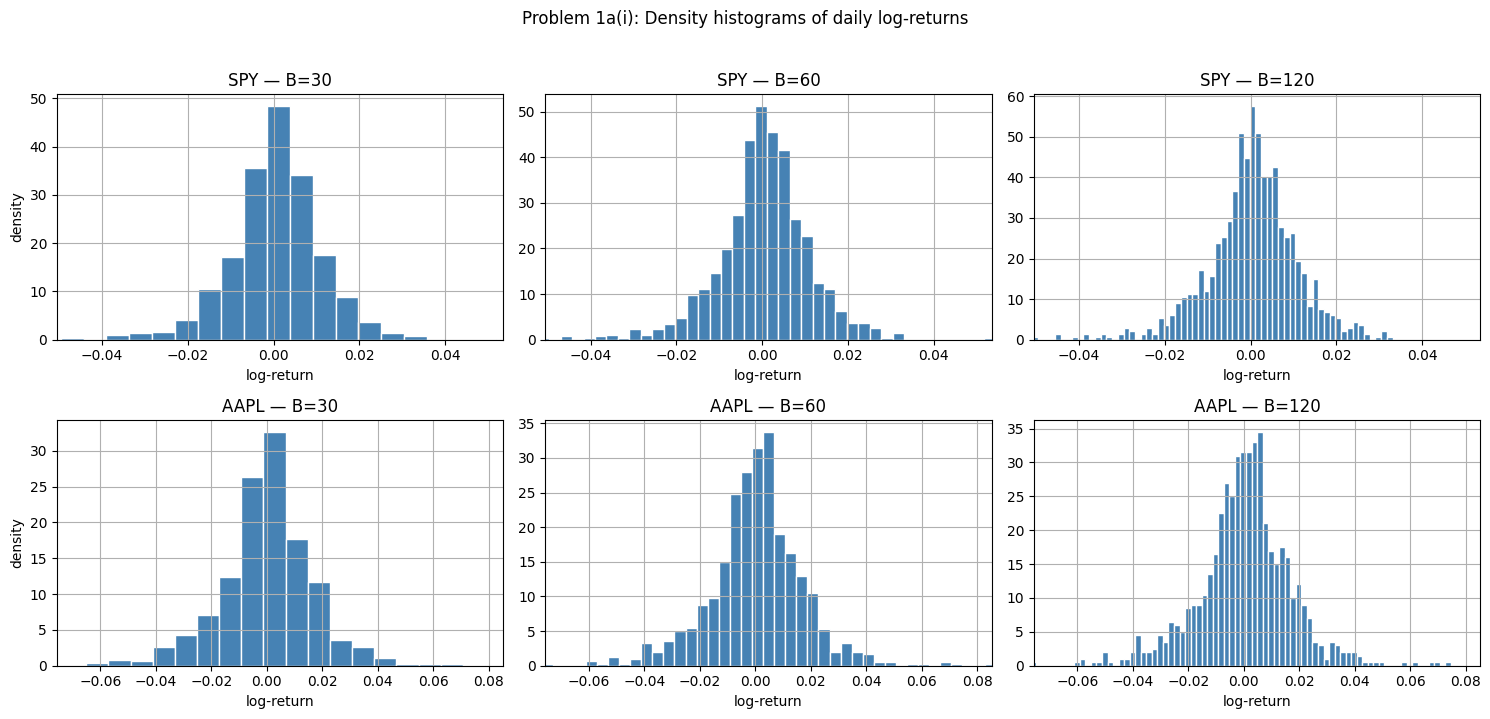

,ticker,B,total_area
0,SPY,30,1.000000
1,SPY,60,1.000000
2,SPY,120,1.000000
3,AAPL,30,1.000000
4,AAPL,60,1.000000
5,AAPL,120,1.000000


In [4]:
B_values = [30, 60, 120]
area_records = []

fig, axes = plt.subplots(len(TICKERS), len(B_values), figsize=(15, 7))

for i, ticker in enumerate(TICKERS):
    r = returns[ticker]
    x_lo, x_hi = r.quantile([0.001, 0.999])
    for j, B in enumerate(B_values):
        ax = axes[i, j]
        # bins span the full sample range; the quantiles only set the display window
        counts, bin_edges, _ = ax.hist(
            r, bins=B, density=True, color="steelblue", edgecolor="white"
        )
        area = np.sum(counts * np.diff(bin_edges))
        area_records.append({"ticker": ticker, "B": B, "total_area": area})

        ax.set_xlim(x_lo, x_hi)
        ax.set_title(f"{ticker} — B={B}")
        ax.set_xlabel("log-return")
        if j == 0:
            ax.set_ylabel("density")

fig.suptitle("Problem 1a(i): Density histograms of daily log-returns", y=1.02)
fig.tight_layout()
plt.show()

# iii) numerical check that each histogram integrates to one
area_check = pd.DataFrame(area_records)
area_check

**Discussion (center/tails as $B$ increases).**

As $B$ increases from $30$ to $60$ to $120$, the center and tails behave differently, consistent with the histograms produced. In the center, where most of the daily log-returns are concentrated, the peak becomes taller: at $B=30$ the shape is a single smooth hump, while at $B=120$ adjacent bins have jumps in height, which refers to sampling noise from narrower bins. In the tails, the effect is more notable: at $B=30$ the tail bins are wide and few, giving a smooth decay, whereas at $B=120$ the tail bins become sparse enough that many contain only one or two observations, producing visible gaps between populated bins. This is more extreme for AAPL than SPY, since AAPL's returns are more dispersed, leaving even fewer observations in the tail bins. 
Overall, this shows the effect that fewer bins oversmooth both center and tails, while more bins introduce noise that appears first and most visibly where data is sparsest.

### b) Kernel density estimates (bandwidth comparison)

Using `scipy.stats.gaussian_kde`, overlay KDE curves for $h = c\, h_{\text{Scott}}$,
$c \in \{0.5, 1, 2\}$, on the same axes for each asset, and comment on the effect of
changing the bandwidth.

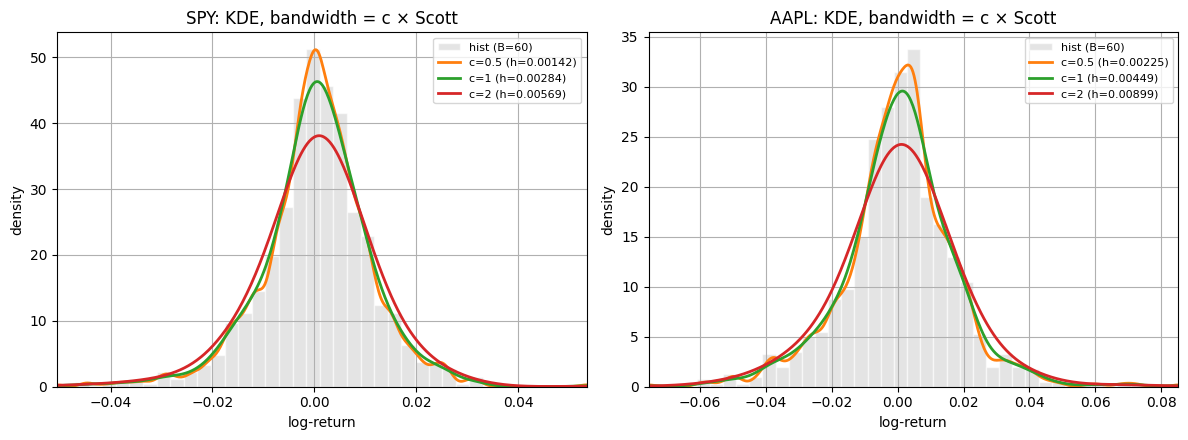

,ticker,c,h
0,SPY,0.500000,0.001422
1,SPY,1.000000,0.002844
2,SPY,2.000000,0.005688
3,AAPL,0.500000,0.002247
4,AAPL,1.000000,0.004493
5,AAPL,2.000000,0.008986


In [5]:
c_values = [0.5, 1, 2]
colors = {0.5: "tab:orange", 1: "tab:green", 2: "tab:red"}

fig, axes = plt.subplots(1, len(TICKERS), figsize=(12, 4.5))
h_records = []

for ax, ticker in zip(axes, TICKERS):
    r = returns[ticker]
    x_lo, x_hi = r.quantile([0.001, 0.999])
    x_grid = np.linspace(x_lo, x_hi, 500)

    # light backdrop for visual reference only
    ax.hist(r, bins=60, density=True, color="lightgray", edgecolor="white",
            alpha=0.6, label="hist (B=60)")

    # gaussian_kde's scalar bw_method IS the covariance factor, so passing
    # c * scotts_factor gives bandwidth h = c * h_Scott directly
    scotts_factor = st.gaussian_kde(r).scotts_factor()
    h_scott = scotts_factor * r.std(ddof=1)

    for c in c_values:
        kde = st.gaussian_kde(r, bw_method=c * scotts_factor)
        h = c * h_scott
        h_records.append({"ticker": ticker, "c": c, "h": h})
        ax.plot(x_grid, kde(x_grid), color=colors[c], lw=2,
                label=f"c={c} (h={h:.5f})")

    ax.set_xlim(x_lo, x_hi)
    ax.set_title(f"{ticker}: KDE, bandwidth = c × Scott")
    ax.set_xlabel("log-return")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

pd.DataFrame(h_records)

**Discussion (effect of bandwidth).**

### c) Choice of bandwidth

Choose one value of $c$ you consider reasonable and justify your choice, addressing:

i) which features of the distribution you are trying to represent;

ii) the trade-off between the center and the tails.

**Justification.**

for the AAPL I'd chose the the KDE with bandwidth c=0.5 because is in between a nice variability and a smoother 

### d) Proofs: mean and variance of the KDE

For a fixed sample $r_1,\dots,r_n$, $h>0$, and a symmetric density $K$ (i.e. $K(u)=K(-u)$)
with finite second moment $m_2(K) := \int_{-\infty}^{\infty} u^2 K(u)\,du < \infty$, and
$$\widehat f_h(x) = \frac{1}{nh}\sum_{t=1}^n K\!\left(\frac{x-r_t}{h}\right), \qquad
\bar r = \frac{1}{n}\sum_{t=1}^n r_t:$$

i) Prove $\mu_h := \int_{-\infty}^{\infty} x\,\widehat f_h(x)\,dx = \bar r$.

ii) Prove $v_h := \int_{-\infty}^{\infty} (x-\mu_h)^2 \widehat f_h(x)\,dx =
\frac{1}{n}\sum_{t=1}^n (r_t-\bar r)^2 + h^2 m_2(K)$.

iii) Calculate $m_2(K)$ for the triangular kernel $K(u)=(1-|u|)\mathbf 1\{|u|\le 1\}$ and
for the Gaussian kernel $K(u)=\phi(u)$. What happens to the mean and the additional
variance due to smoothing when $h$ is doubled? Does the total variance quadruple?

*Hint: substitute $u=(x-r_t)/h$ and use symmetry to show $\int_{-\infty}^{\infty} u K(u)\,du = 0$.*

**i) Proof.**

**ii) Proof.**

**iii) Calculation and discussion.**

## Problem 2

### a) MLE fits: Gaussian and Student-t

For each asset, fit a univariate Gaussian and a univariate Student-t distribution by
maximum likelihood and report the estimated parameters.

### b) Overlay fitted densities

Overlay both fitted densities on one of the density histograms from Problem 1a) (using the
empirical 0.1st-99.9th percentile range). Where do the fitted models differ most; which
asset shows the stronger departure from Gaussianity?

**Discussion.**

### c) Tail probabilities vs. empirical quantiles

Compute $\mathbb P(R \le q^{\text{emp}}_{0.01})$ and $\mathbb P(R \ge q^{\text{emp}}_{0.99})$
under each fitted model, compare with the empirical values of 1%, and discuss which fitted
model better represents the tails.

**Discussion.**

### d) Direct verification of the Gaussian MLE

Verify the Gaussian MLE calculation from 2a) directly by computing
$\hat\mu = \bar r$ and $\hat\sigma_{\text{MLE}} = \sqrt{\frac{1}{n}\sum_{t=1}^n (r_t-\bar r)^2}$.

### e) Critique of a Student-t MLE snippet

Discuss what the following code tries to do, identify the problems in the code, and
propose a corrected version.

```python
def nll(theta, x):
    nu, loc, scale = theta
    return -np.sum(stats.t.logpdf(x, df=nu, loc=loc, scale=scale))

theta0 = np.array([2.0, 0.0, 0.0])
res = scipy.optimize.minimize(nll, theta0, args=(r,))
```

**Discussion of the problems.**

## Problem 3

### a) Normal and Student-t Q–Q plots

For each asset, construct a Normal Q–Q plot and a Student-t Q–Q plot using the fitted
models from Problem 2a). State what is shown on each axis.

### b) Comparing the Q–Q plots

Does the Student-t model reduce the tail deviations? Does either symmetric model explain
visible asymmetry?

**Discussion.**

### c) Reading unknown Q–Q plots

For the given Normal Q–Q plot and Exponential Q–Q plot of unknown datasets, describe what
features of the underlying distribution can be inferred from each.

**Discussion.**

## Problem 4

Define the one-day loss $L_t = -r_t$. Use confidence levels $\alpha \in \{0.95, 0.99\}$
for Value-at-Risk (VaR) and Expected Shortfall (ES) computations, for each asset from
Problem 1.

### a) Empirical VaR and ES

### b) Gaussian-model VaR and ES

### c) Comparison

Compare the empirical and Gaussian values. Check that ES is at least as large as VaR at
each level, and interpret any discrepancy between empirical and Gaussian tail risk.

**Discussion.**

### d) Qualitative prediction for the Student-t risk estimate

Use the fitted Student-t density and the Q–Q plots to predict qualitatively whether a
Student-t risk estimate would be closer to the empirical value.

**Discussion.**